# AP power

**author**: laquitainesteeve@gmail.com

**purpose**: Validation of power in action potential (AP) freq.

**Execution time**: A few minutes

**Tested on**: 
- Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz)

**Resources required**: 
- multi-node processing (mpi)
- more than 180 GB RAM.



Parameters:

- Entire traces
- bandpass-filtering: 300 - Nyquist
- AP freq band 300 - 2000

## Setup

1. Setup "_spikebias_" virtual environment
2. Setup jupyter kernel _$python -m ipykernel install --user --name spikebias --display-name "spikebias"_
3. Download recordings: "_notebooks/0_download_recordings.ipynb_"
4. Pre-compute power spectral densities with: "_src/pipes/validation/psd/multiprocess.py_"

note: 300 and 100 Hz cutoff produce similar statistical results

In [2]:
# import libs
%load_ext autoreload
%autoreload 2

# import packages
import os
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import spikeinterface as si
import copy
import multiprocessing
import torch
import seaborn as sns
import pandas as pd
from scipy.stats import kruskal # stats
import scikit_posthocs as sp
import warnings

# silence warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

# setup plot parameters
matplotlib.rcParams['agg.path.chunksize'] = 10000

# move to PROJECT PATH
PROJ_PATH = "/home/steeve/steeve/epfl/code/spikebias"
os.chdir(PROJ_PATH)

# setup intermediate dataset path
PLOT_DATA_PATH_NPX = "dataset/02_figure_dataset/fig2r_data_APpower_npx.parquet"

# pipeline parameters
SAVE_FIG = True

# setup FIGURE SETTINGS
FIG_SIZE = (1.5, 1.5)

# setup experiment colors
cl = dict()
cl["COLOR_NV"] = [0.6, 0.6, 0.6]
cl["COLOR_NS"] = [0.9, 0.14, 0.15]
cl["COLOR_NB"] = [0.22, 0.5, 0.72] # blue
cl["COLOR_NE"] = [1, 0.49, 0] # orange
cl["COLOR_MEDIAN"] = (1, 0.76, 0)
cl["COLOR_HV"] = "k" # black
cl["COLOR_HS"] = np.array([26, 152, 80]) / 255 # green

# axes aesthetics
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6  # 5-7 with Nature neuroscience as reference
plt.rcParams["lines.linewidth"] = 0.5 # typically 0.5 - 1 pt
plt.rcParams["axes.linewidth"] = 0.5 # typically 0.5 - 1 pt
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1
N_MAJOR_TICKS = 4
N_MINOR_TICKS = 12

# setup figure settings
savefig_cfg = {"transparent":True, "dpi":400, "bbox_inches": "tight"}
legend_cfg = {"frameon": False, "handletextpad": 0.1}
tight_layout_cfg = {"pad": 0.5}
LG_FRAMEON = False              # no legend frame

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Clear RAM

In [3]:
# clear ram
import getpass; password = getpass.getpass("Enter your sudo password: ")
!sync; echo {password} | sudo -S sh -c 'echo 1 > /proc/sys/vm/drop_caches'

[sudo] password for steeve: Sorry, try again.
[sudo] password for steeve: 
sudo: no password was provided
sudo: 1 incorrect password attempt


## Load dataset

In [4]:
plot_data = pd.read_parquet(PLOT_DATA_PATH_NPX)

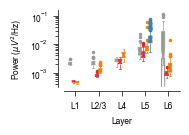

In [5]:
# lower and top of frequency band for Action potential

c_bot = 300  # spike with a period of 3 ms
c_up = 2000  # spike with a period of 0.5 mscalend

# standardize
plot_data["Layer"][plot_data["Layer"] == "L2_3"] = "L2/3"

# plot
fig, ax = plt.subplots(1, 1, figsize=(1.5, 1))

ax = sns.boxplot(
    ax=ax,
    data=plot_data,
    x="Layer",
    y="power",
    hue="Experiment",
    notch=True,
    hue_order=["M", "NS", "E", "S"],
    palette=[cl["COLOR_NV"], cl["COLOR_NS"], cl["COLOR_NE"], cl["COLOR_NB"]],
    width=0.6,
    linewidth=0.5,
    flierprops={
        "marker": ".",
        "markersize": 3,
    },
)
ax.set_yscale("log")

# axes
ax.spines[["top", "right"]].set_visible(False)
ax.legend("", frameon=False)

# disconnect axes (R style)
ax.spines["bottom"].set_position(("axes", -0.05))
ax.yaxis.set_ticks_position("left")
ax.spines["left"].set_position(("axes", -0.05))

# minor ticks
locmin = matplotlib.ticker.LogLocator(
    base=10.0,
    subs=np.arange(0, 1.1, 0.1),
    numticks=5,
)
ax.tick_params(which="both")
ax.yaxis.set_minor_locator(locmin)

# customize the boxplot
p = 0
for box in ax.patches:
    if box.__class__.__name__ == "PathPatch":
        # a list item for each layer group
        if p in [0, 1, 2, 3, 4]:
            box.set_edgecolor(cl["COLOR_NV"])
            # Each box has 6 associated Line2D objects
            # (to make the whiskers, fliers, etc.)
            # Loop over them here, and use the same colour
            # as above
            # group 1 (NV)
            for k in range(6 * p, 6 * (p + 1)):
                ax.lines[k].set_color(cl["COLOR_NV"])  # box
                ax.lines[k].set_mfc(cl["COLOR_NV"])  # whisker
                ax.lines[k].set_mec(cl["COLOR_NV"])  # fliers
            p += 1
        elif p in [5, 6, 7, 8, 9]:
            # group 2 (NS)
            box.set_edgecolor(cl["COLOR_NS"])
            for k in range(6 * p, 6 * (p + 1)):
                ax.lines[k].set_color(cl["COLOR_NS"])
                ax.lines[k].set_mfc(cl["COLOR_NS"])
                ax.lines[k].set_mec(cl["COLOR_NS"])
            p += 1
        elif p in [10, 11, 12, 13, 14]:
            box.set_edgecolor(cl["COLOR_NE"])
            for k in range(6 * p, 6 * (p + 1)):
                ax.lines[k].set_color(cl["COLOR_NE"])
                ax.lines[k].set_mfc(cl["COLOR_NE"])
                ax.lines[k].set_mec(cl["COLOR_NE"])
            p += 1
        elif p in [15]:
            box.set_edgecolor(cl["COLOR_NB"])
            for k in range(6 * p, 6 * (p + 1)):
                ax.lines[k].set_color(cl["COLOR_NB"])
                ax.lines[k].set_mfc(cl["COLOR_NB"])
                ax.lines[k].set_mec(cl["COLOR_NB"])
            p += 1

# legend
ax.set_ylabel("Power ($\u03bcV^2$/Hz)")
ax.set_xlabel("Layer")

# save
if SAVE_FIG:
    plt.savefig("figures/8_source_data/fig2r/fig2r.svg", **savefig_cfg)

In [6]:
# display source data
display(plot_data)

# save to Excel
plot_data.to_excel(
    "figures/8_source_data/fig2r/fig2r.xlsx",
    index=False,
)

,power,Layer,Experiment
0,0.001992,L1,M
1,0.002970,L1,M
2,0.002130,L1,M
3,0.001977,L1,M
4,0.001993,L1,M
...,...,...,...
379,0.011765,L5,S
380,0.020034,L5,S
381,0.010100,L5,S
382,0.017680,L5,S


### Hypothesis testing

In [7]:
def get_power(df, exp, layer):
    return df[(df.Experiment == exp) & (df.Layer == layer)]["power"].values


def get_kk(df, exp):
    """kruskall wallis test"""
    h, p = kruskal(
        get_power(df, exp, "L1"),
        get_power(df, exp, "L2/3"),
        get_power(df, exp, "L4"),
        get_power(df, exp, "L5"),
        get_power(df, exp, "L6"),
    )

    print(f"H={h}, p={p}")
    print(f"""N_L1 = {len(get_power(df, exp, "L1"))} sites""")
    print(f"""N_L23 = {len(get_power(df, exp, "L2/3"))} sites""")
    print(f"""N_L4 = {len(get_power(df, exp, "L4"))} sites""")
    print(f"""N_L5 = {len(get_power(df, exp, "L5"))} sites""")
    print(f"""N_L6 = {len(get_power(df, exp, "L6"))} sites""")


def get_posthoc_dunn_holm_sidak(df, exp):
    """posthoc test after kruskall wallis with Dunn and holm_sidak
    multiple comparison correction of p-values

    Args:
        df (_type_): _description_
        exp (_type_): _description_

    Returns:
        _type_: _description_
    """
    data = [
        get_power(df, exp, "L1"),
        get_power(df, exp, "L2/3"),
        get_power(df, exp, "L4"),
        get_power(df, exp, "L5"),
        get_power(df, exp, "L6"),
    ]
    # holm sidak method has more power than Bonferroni which is more conservative
    # Non-significance can indicate subtle differences, power issues, samll sample size,
    # or the balancing be due to how the Holm-Sidak correction controls Type I errors
    # while retaining power.
    # we can still look at the p-values to identify trends.
    df = sp.posthoc_dunn(data, p_adjust="holm-sidak")
    df.columns = ["L1", "L2/3", "L4", "L5", "L6"]
    df.index = ["L1", "L2/3", "L4", "L5", "L6"]
    return df


def ci95(data):
    return 1.96 * np.nanstd(data) / np.sqrt(np.sum(~np.isnan(data)))


def get_medians_and_ci95(plot_data, exp, feature: str):
    layers = ["L1", "L2/3", "L4", "L5", "L6"]
    stats = ""
    record = []
    for layer in layers:
        feature_data = plot_data[
            (plot_data.Experiment == exp) & (plot_data.Layer == layer)
        ][feature]
        stats += f"{np.round(feature_data.median()*10000)/10000} $\pm$ {np.round(ci95(feature_data),6)}, "
        record.append(np.round(feature_data.median() * 10000) / 10000)
    print(stats)
    return record

### Power changes across layers?

In [9]:
print("\n--------------------MS--------------------\n")
get_kk(plot_data, "M")
display(get_posthoc_dunn_holm_sidak(plot_data, "M"))
m_m = get_medians_and_ci95(plot_data, "M", "power")

print("\n--------------------NS--------------------\n")
get_kk(plot_data, "NS")
display(get_posthoc_dunn_holm_sidak(plot_data, "NS"))
m_ns = get_medians_and_ci95(plot_data, "NS", "power")

print("\n--------------------E--------------------\n")
get_kk(plot_data, "E")
display(get_posthoc_dunn_holm_sidak(plot_data, "E"))
m_e = get_medians_and_ci95(plot_data, "E", "power")

print("\n--------------------S--------------------\n")
m_s = get_medians_and_ci95(plot_data, "S", "power")


--------------------MS--------------------

H=129.92523257168455, p=4.040099767668325e-27
N_L1 = 10 sites
N_L23 = 42 sites
N_L4 = 34 sites
N_L5 = 42 sites
N_L6 = 98 sites


,L1,L2/3,L4,L5,L6
L1,1.000000e+00,9.401085e-01,3.662062e-01,7.899339e-07,1.511354e-06
L2/3,9.401085e-01,1.000000e+00,1.117843e-01,4.488586e-16,1.123281e-18
L4,3.662062e-01,1.117843e-01,1.000000e+00,6.154217e-08,3.234225e-08
L5,7.899339e-07,4.488586e-16,6.154217e-08,1.000000e+00,6.361670e-01
L6,1.511354e-06,1.123281e-18,3.234225e-08,6.361670e-01,1.000000e+00


0.002 $\pm$ 0.00025, 0.0022 $\pm$ 0.000199, 0.0028 $\pm$ 0.000141, 0.0052 $\pm$ 0.001176, 0.004 $\pm$ 0.004328, 

--------------------NS--------------------

H=163.807248574077, p=2.229879737681093e-34
N_L1 = 16 sites
N_L23 = 47 sites
N_L4 = 19 sites
N_L5 = 52 sites
N_L6 = 68 sites


,L1,L2/3,L4,L5,L6
L1,1.000000e+00,8.457515e-03,5.672853e-11,1.971577e-22,1.447584e-05
L2/3,8.457515e-03,1.000000e+00,5.165319e-07,4.852058e-22,4.283673e-02
L4,5.672853e-11,5.165319e-07,1.000000e+00,4.727928e-02,3.392579e-04
L5,1.971577e-22,4.852058e-22,4.727928e-02,1.000000e+00,2.932561e-16
L6,1.447584e-05,4.283673e-02,3.392579e-04,2.932561e-16,1.000000e+00


0.0005 $\pm$ 1.7e-05, 0.0008 $\pm$ 3.2e-05, 0.0024 $\pm$ 0.000277, 0.0041 $\pm$ 0.000499, 0.001 $\pm$ 5.2e-05, 

--------------------E--------------------

H=155.25300894491681, p=1.5233736058259884e-32
N_L1 = 16 sites
N_L23 = 47 sites
N_L4 = 19 sites
N_L5 = 52 sites
N_L6 = 68 sites


,L1,L2/3,L4,L5,L6
L1,1.000000e+00,2.657828e-03,1.796415e-10,3.765473e-22,2.782006e-05
L2/3,2.657828e-03,1.000000e+00,1.025457e-05,1.311189e-19,1.138043e-01
L4,1.796415e-10,1.025457e-05,1.000000e+00,6.577775e-02,4.587452e-04
L5,3.765473e-22,1.311189e-19,6.577775e-02,1.000000e+00,1.191588e-16
L6,2.782006e-05,1.138043e-01,4.587452e-04,1.191588e-16,1.000000e+00


0.0005 $\pm$ 1.8e-05, 0.0012 $\pm$ 0.000103, 0.0041 $\pm$ 0.00053, 0.0072 $\pm$ 0.002427, 0.0015 $\pm$ 0.000398, 

--------------------S--------------------

nan $\pm$ nan, nan $\pm$ nan, nan $\pm$ nan, 0.0142 $\pm$ 0.001026, nan $\pm$ nan, 


## Are models and in vivo power the same?

In [10]:
from scipy.stats import kruskal
import scikit_posthocs as sp


def count_sites(df, exp, layer):
    return len(df[(df["Experiment"] == exp) & (df["Layer"] == layer)])


def get_power(df, exp, layer):
    return df[(df["Experiment"] == exp) & (df["Layer"] == layer)]["power"].values


def get_kk_compare_exps(df, layer):
    """kruskall wallis test"""
    h, p = kruskal(
        get_power(df, "M", layer),
        get_power(df, "NS", layer),
        get_power(df, "E", layer),
    )
    print(f"H={h}, p={p}")
    print(f"""N_NS = {count_sites(df, "NS", layer)} sites""")
    print(f"""N_E = {count_sites(df, "E", layer)} sites""")
    print(f"""N_M = {count_sites(df, "M", layer)} sites""")


def get_posthoc_dunn_holm_sidak_compare_exps(plot_data, layer):
    """posthoc test after kruskall wallis with Dunn and holm_sidak
    multiple comparison correction of p-values

    Args:
        plot_data (_type_): _description_
        exp (_type_): _description_

    Returns:
        _type_: _description_
    """
    data = [
        get_power(plot_data, "M", layer),
        get_power(plot_data, "NS", layer),
        get_power(plot_data, "E", layer),
    ]
    # holm sidak method has more power than Bonferroni which is more conservative
    # Non-significance can indicate subtle differences, power issues, samll sample size,
    # or the balancing be due to how the Holm-Sidak correction controls Type I errors
    # while retaining power.
    # we can still look at the p-values to identify trends.
    df = sp.posthoc_dunn(data, p_adjust="holm-sidak")
    df.columns = ["M", "NS", "E"]
    df.index = ["M", "NS", "E"]
    return df


def get_posthoc_dunn_holm_sidak_compare_exps_l5(plot_data, layer):
    """posthoc test after kruskall wallis with Dunn and holm_sidak
    multiple comparison correction of p-values

    Args:
        plot_data (_type_): _description_
        exp (_type_): _description_

    Returns:
        _type_: _description_
    """
    data = [
        get_power(plot_data, "M", layer),
        get_power(plot_data, "NS", layer),
        get_power(plot_data, "E", layer),
        get_power(plot_data, "S", layer),
    ]
    # holm sidak method has more power than Bonferroni which is more conservative
    # Non-significance can indicate subtle differences, power issues, samll sample size,
    # or the balancing be due to how the Holm-Sidak correction controls Type I errors
    # while retaining power.
    # we can still look at the p-values to identify trends.
    df = sp.posthoc_dunn(data, p_adjust="holm-sidak")
    df.columns = ["M", "NS", "E", "S"]
    df.index = ["M", "NS", "E", "S"]
    return df

In [11]:
print("------LAYER 1:------\n")

# kruskall-wallis
# perform Dunn's posthoc test using a holm-sidak correction for the p-values
# to identify the layer amplitudes that significantly deviate from others
get_kk_compare_exps(plot_data, "L1")
display(get_posthoc_dunn_holm_sidak_compare_exps(plot_data, "L1"))


print("\n------LAYER 2/3:------\n")

get_kk_compare_exps(plot_data, "L2/3")
display(get_posthoc_dunn_holm_sidak_compare_exps(plot_data, "L2/3"))

print("\n------LAYER 4:------\n")

get_kk_compare_exps(plot_data, "L4")
display(get_posthoc_dunn_holm_sidak_compare_exps(plot_data, "L4"))

print("\n------LAYER 5:------\n")

get_kk_compare_exps(plot_data, "L5")
display(get_posthoc_dunn_holm_sidak_compare_exps_l5(plot_data, "L5"))

print("\n------LAYER 6:------\n")

get_kk_compare_exps(plot_data, "L6")
display(get_posthoc_dunn_holm_sidak_compare_exps(plot_data, "L6"))

------LAYER 1:------

H=24.838039867109643, p=4.04099368922823e-06
N_NS = 16 sites
N_E = 16 sites
N_M = 10 sites


,M,NS,E
M,1.000000,0.000766,0.000002
NS,0.000766,1.000000,0.112950
E,0.000002,0.112950,1.000000



------LAYER 2/3:------

H=107.08284632380673, p=5.5879867484034746e-24
N_NS = 47 sites
N_E = 47 sites
N_M = 42 sites


,M,NS,E
M,1.000000e+00,1.637610e-24,1.175755e-06
NS,1.637610e-24,1.000000e+00,3.707141e-08
E,1.175755e-06,3.707141e-08,1.000000e+00



------LAYER 4:------

H=29.866152084481968, p=3.270750956068126e-07
N_NS = 19 sites
N_E = 19 sites
N_M = 34 sites


,M,NS,E
M,1.000000,0.234684,0.000011
NS,0.234684,1.000000,0.000001
E,0.000011,0.000001,1.000000



------LAYER 5:------

H=45.1844184610469, p=1.5428659592959273e-10
N_NS = 52 sites
N_E = 52 sites
N_M = 42 sites


,M,NS,E,S
M,1.000000e+00,1.859818e-01,1.859818e-01,1.319324e-18
NS,1.859818e-01,1.000000e+00,4.852902e-03,1.763538e-33
E,1.859818e-01,4.852902e-03,1.000000e+00,4.199071e-15
S,1.319324e-18,1.763538e-33,4.199071e-15,1.000000e+00



------LAYER 6:------

H=167.42697131225657, p=4.402456958126537e-37
N_NS = 68 sites
N_E = 68 sites
N_M = 98 sites


,M,NS,E
M,1.000000e+00,8.720499e-36,4.262929e-15
NS,8.720499e-36,1.000000e+00,1.942785e-05
E,4.262929e-15,1.942785e-05,1.000000e+00


# Summary statistics

In [11]:
def pc(x1, x2):
    return (x1 - x2) / x1 * 100

In [12]:
# NEUROPIXELS  ------------------

L1_ns = pc(m_m[0], m_ns[0])
L1_e = pc(m_m[0], m_e[0])

L23_ns = pc(m_m[1], m_ns[1])
L23_e = pc(m_m[1], m_e[1])

L4_ns = pc(m_m[2], m_ns[2])
L4_e = pc(m_m[2], m_e[2])

L5_ns = pc(m_m[3], m_ns[3])
L5_e = pc(m_m[3], m_e[3])

L6_ns = pc(m_m[4], m_ns[4])
L6_e = pc(m_m[4], m_e[4])

print(
    "Models median power are on average ",
    -np.round(
        np.median([L1_ns, L1_e, L23_ns, L23_e, L4_ns, L4_e, L5_ns, L5_e, L6_ns, L6_e]),
        1,
    ),
    "% Marques-Smith data",
)

print(
    "Models median power are on average ",
    -np.round(np.median([L1_ns, L1_e, L23_ns, L23_e, L6_ns, L6_e]), 1),
    "% Marques-Smith data across L1, L23, L6",
)

print(
    "Models median power are on average ",
    -np.round(np.median([L4_ns, L4_e, L5_ns, L5_e]), 1),
    "% Marques-Smith data, across L4 and L5",
)

Models median power are on average  -54.0 % Marques-Smith data
Models median power are on average  -69.3 % Marques-Smith data across L1, L23, L6
Models median power are on average  12.1 % Marques-Smith data, across L4 and L5


In [ ]:
0.0002 $\pm$ 2.1e-05, 0.0002 $\pm$ 1.5e-05, 0.0002 $\pm$ 7e-06, 0.0003 $\pm$ 2.7e-05, 0.0002 $\pm$ 4.7e-05, 


In [ ]:
# power ratio between Marques-smith and Horvath
median_power_marques = np.median(np.array([2e-3, 2e-3, 2.8e-3, 5.2e-3, 4e-3]))
median_power_horvath = np.median(np.array([0.01, 0.05, 0.08, 0.09, 0.06]))

print(median_power_horvath / median_power_marques)

21.428571428571427
